cuda


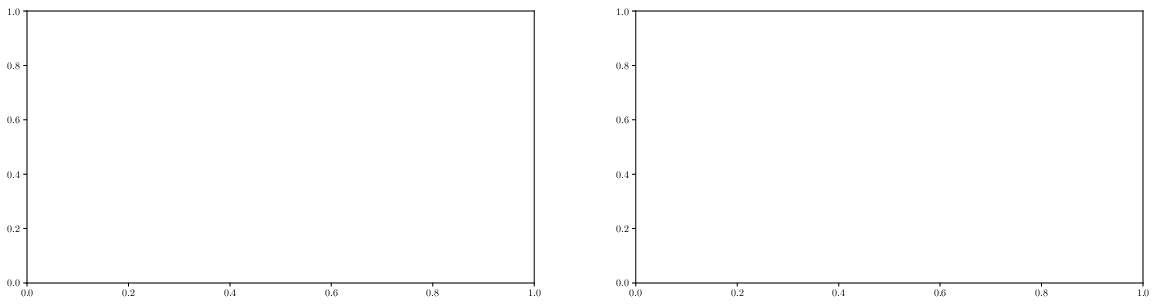

In [45]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list

def fit_powerlaw(x, y, n_bootstrap=1000, rng=None):
    """
    Fit y = a * x^alpha on log-log scale.
    Returns alpha with two error estimates:
      - se_cov:  standard error from polyfit's covariance matrix
      - se_boot: standard error from bootstrap resampling
    """
    rng = np.random.default_rng(rng)
    lx, ly = np.log(x), np.log(y)

    # ── Covariance-based SE ───────────────────────────────────────────────────
    coeffs, cov = np.polyfit(lx, ly, deg=1, cov=True)
    alpha    = coeffs[0]          # power-law exponent
    se_cov   = np.sqrt(cov[0, 0]) # SE on the slope

    # ── Bootstrap SE ─────────────────────────────────────────────────────────
    idx       = np.arange(len(x))
    boot_alphas = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(idx, size=len(idx), replace=True)
        boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]

    se_boot = boot_alphas.std(ddof=1)  # ddof=1 → unbiased sample std

    return alpha, se_cov, se_boot, boot_alphas



fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

# Errors for GPT2

In [26]:
T = 128
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
p_list1 = results['data']
error_list1 = results['losses']

print(f"T={T}, {len(p_list)} points")
print(p_list1)

T = 256
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
p_list2 = results['data']
error_list2 = results['losses']

print(f"T={T}, {len(p_list)} points")
print(p_list2)

T = 512
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
p_list3 = results['data']
error_list3 = results['losses']

print(f"T={T}, {len(p_list)} points")
print(p_list3)

T=128, 10 points
[262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728, 268435456, 529203200]
T=256, 10 points
[262144, 1048576, 4194304, 16777216, 67108864, 268435456]
T=512, 10 points
[1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728, 268435456, 529203200]


In [55]:
# lower envelope
p_list = p_list1
error_list = error_list1
error_list[4] = error_list2[2]
error_list[5] = error_list3[3]
error_list[6] = error_list2[3]
error_list[7] = error_list3[5]
error_list[8] = error_list3[6]
error_list[9] = error_list3[7]
error_list[10] = error_list3[8]
error_list[11] = error_list3[9]

for end in range(5,13):

    print(f'\n {end} points, fit:')
    rng = np.random.default_rng(42)
    x = np.array(p_list[:end])
    y = np.array([loss.mean() for loss in error_list[:end]])
    alpha, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, rng=rng)

    print(f"alpha       = {alpha:.4f}")
    print(f"SE (cov)    = {se_cov:.4f}   → {alpha:.4f} ± {se_cov:.4f}")
    print(f"SE (boot)   = {se_boot:.4f}  → {alpha:.4f} ± {se_boot:.4f}")

    # Bootstrap also gives you percentile CIs for free (asymmetric if needed):
    lo, hi = np.percentile(boot_dist, [2.5, 97.5])
    print(f"95% boot CI = [{lo:.4f}, {hi:.4f}]")
#     fit = np.polyfit(np.log(np.array(x_list)), np.log(np.array(y_list)), 1)
#     print(f'n={end+1}, fit:', fit)


 5 points, fit:
alpha       = -0.1853
SE (cov)    = 0.0027   → -0.1853 ± 0.0027
SE (boot)   = 0.0078  → -0.1853 ± 0.0078
95% boot CI = [-0.1946, -0.1770]

 6 points, fit:
alpha       = -0.1840
SE (cov)    = 0.0019   → -0.1840 ± 0.0019
SE (boot)   = 0.0026  → -0.1840 ± 0.0026
95% boot CI = [-0.1893, -0.1786]

 7 points, fit:


/tmp/ipykernel_338953/3422379608.py:151: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]


alpha       = -0.1827
SE (cov)    = 0.0016   → -0.1827 ± 0.0016
SE (boot)   = 0.0022  → -0.1827 ± 0.0022
95% boot CI = [-0.1869, -0.1786]

 8 points, fit:
alpha       = -0.1793
SE (cov)    = 0.0023   → -0.1793 ± 0.0023
SE (boot)   = 0.0032  → -0.1793 ± 0.0032
95% boot CI = [-0.1851, -0.1730]

 9 points, fit:
alpha       = -0.1760
SE (cov)    = 0.0026   → -0.1760 ± 0.0026
SE (boot)   = 0.0037  → -0.1760 ± 0.0037
95% boot CI = [-0.1838, -0.1689]

 10 points, fit:
alpha       = -0.1719
SE (cov)    = 0.0031   → -0.1719 ± 0.0031
SE (boot)   = 0.0044  → -0.1719 ± 0.0044
95% boot CI = [-0.1807, -0.1633]

 11 points, fit:
alpha       = -0.1672
SE (cov)    = 0.0038   → -0.1672 ± 0.0038
SE (boot)   = 0.0053  → -0.1672 ± 0.0053
95% boot CI = [-0.1782, -0.1566]

 12 points, fit:
alpha       = -0.1617
SE (cov)    = 0.0045   → -0.1617 ± 0.0045
SE (boot)   = 0.0063  → -0.1617 ± 0.0063
95% boot CI = [-0.1751, -0.1494]


# Plot Scaling laws with varying context size

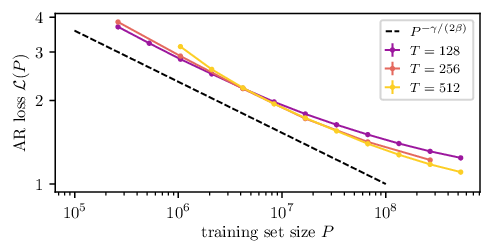

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*4.2, 1*2.2), dpi=120)
# fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 4)              # [0, 1/3, 2/3, 1]
colors4 = cmap(u)                     # shape (4,4) RGBA


# T = 64
# depth = 12

# results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
# p_list = results['data']
# error_list = results['losses']
# ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[0], marker='.', label=fr'$T={T}$')


T = 128
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[1], marker='.', label=fr'$T={T}$')


T = 256
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[2], marker='.', label=fr'$T={T}$')


T = 512
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[3], marker='.', label=fr'$T={T}$')

ax.plot([1e5,1e8],[30*1e5**-(.325/(2*.88)),30*1e8**-(.325/(2*.88))],'k--', label=r'$P^{-\gamma/(2\beta)}$')


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'AR loss $\mathcal{L}(P)$', fontsize=10)
ax.set_xlabel(r'training set size $P$', fontsize=10)

ticks  = [1, 2, 3, 4]
labels = ["1", "2", "3", "4"]  # must match length/order
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


fig.tight_layout()

In [4]:
fig.savefig('tinystories/'+f'L_P__tinystories.BPE8192__GPT2_APE.pdf', bbox_inches="tight")

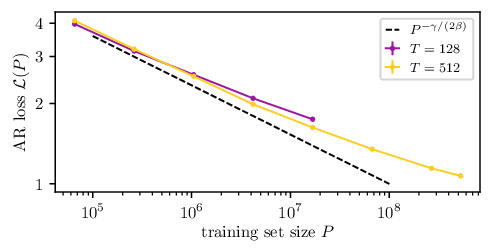

In [6]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*4.2, 1*2.2), dpi=120)
# fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 4)              # [0, 1/3, 2/3, 1]
colors4 = cmap(u)                     # shape (4,4) RGBA

T = 128
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[1], marker='.', label=fr'$T={T}$')


T = 512
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[3], marker='.', label=fr'$T={T}$')

ax.plot([1e5,1e8],[30*1e5**-(.325/(2*.88)),30*1e8**-(.325/(2*.88))],'k--', label=r'$P^{-\gamma/(2\beta)}$')


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'AR loss $\mathcal{L}(P)$', fontsize=10)
ax.set_xlabel(r'training set size $P$', fontsize=10)

ticks  = [1, 2, 3, 4]
labels = ["1", "2", "3", "4"]  # must match length/order
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


fig.tight_layout()

In [7]:
fig.savefig('tinystories/'+f'L_P__tinystories.BPE8192__GPT2_RoPE.pdf', bbox_inches="tight")

/home/cagnetta/anaconda3/envs/llm/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/cagnetta/anaconda3/envs/llm/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


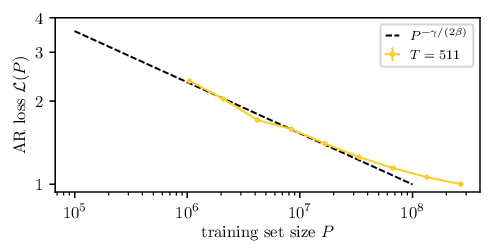

In [8]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*4.2, 1*2.2), dpi=120)
# fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 4)              # [0, 1/3, 2/3, 1]
colors4 = cmap(u)                     # shape (4,4) RGBA


T = 511

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_llama.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[3], marker='.', label=fr'Llama')

ax.plot([1e5,1e8],[30*1e5**-(.325/(2*.88)),30*1e8**-(.325/(2*.88))],'k--', label=r'$P^{-\gamma/(2\beta)}$')


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'AR loss $\mathcal{L}(P)$', fontsize=10)
ax.set_xlabel(r'training set size $P$', fontsize=10)

ticks  = [1, 2, 3, 4]
labels = ["1", "2", "3", "4"]  # must match length/order
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


fig.tight_layout()

In [9]:
fig.savefig('tinystories/'+f'L_P__tinystories.BPE8192__LLAMA.pdf', bbox_inches="tight")

/home/cagnetta/anaconda3/envs/llm/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/cagnetta/anaconda3/envs/llm/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


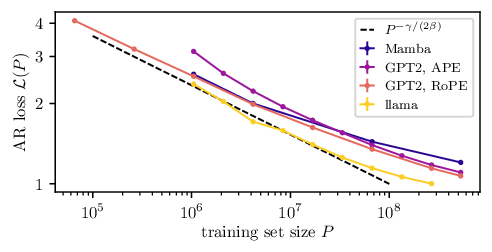

In [118]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig, ax = plt.subplots(1, 1, figsize=(1*4.2, 1*2.2), dpi=120)
# fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
u = np.linspace(0, 1, 4)              # [0, 1/3, 2/3, 1]
colors4 = cmap(u)                     # shape (4,4) RGBA


T = 128
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}_mamba.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[0], marker='.', label=fr'Mamba')


T = 512
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[1], marker='.', label=fr'GPT2, APE')


T = 512
depth = 12

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[2], marker='.', label=fr'GPT2, RoPE')


T = 511

results = torch.load(f"tinystories/learning-curves/learning-curve_tinystories.BPE8192_T{T}_llama.pt")
p_list = results['data']
error_list = results['losses']
ax.errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=colors4[3], marker='.', label=fr'llama')

ax.plot([1e5,1e8],[30*1e5**-(.325/(2*.88)),30*1e8**-(.325/(2*.88))],'k--', label=r'$P^{-\gamma/(2\beta)}$')


ax.legend(fontsize=8, handlelength=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r'AR loss $\mathcal{L}(P)$', fontsize=10)
ax.set_xlabel(r'training set size $P$', fontsize=10)

ticks  = [1, 2, 3, 4]
labels = ["1", "2", "3", "4"]  # must match length/order
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


fig.tight_layout()

# $n$-grams collapse

### GPT2, $T=128$

12 torch.Size([4, 128])


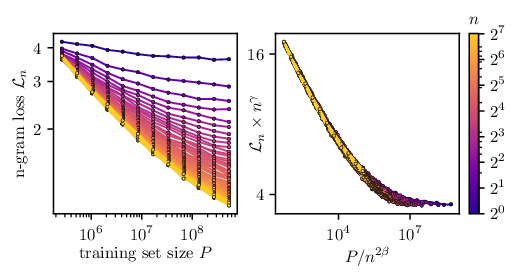

In [57]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

T = 128
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [58]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T128.pdf', bbox_inches="tight")

12 torch.Size([4, 128])


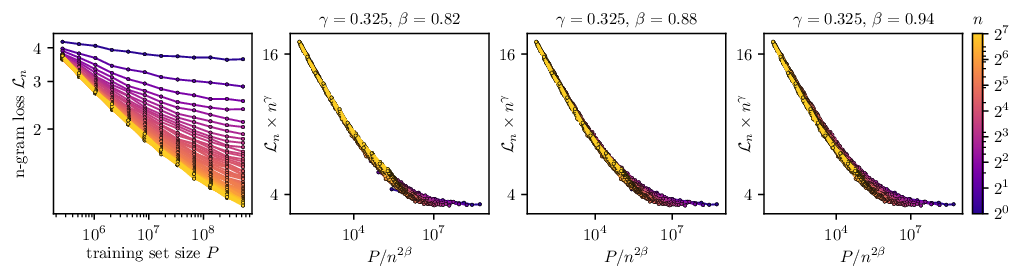

In [59]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 128
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.82)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.88)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.325$, $\beta=0.82$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.325$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [60]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T128__error_beta.pdf', bbox_inches="tight")

12 torch.Size([4, 128])


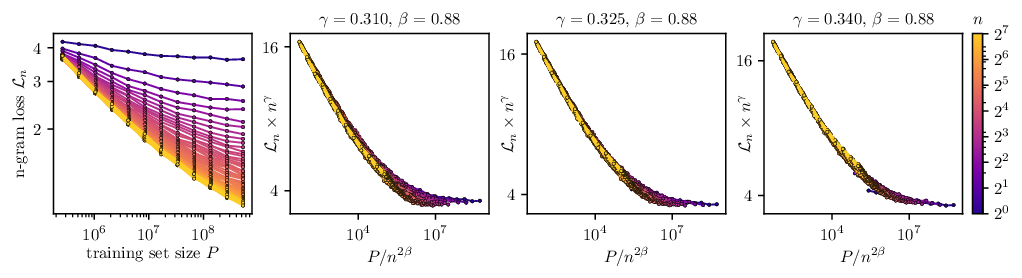

In [61]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 128
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.310 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.340 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.310$, $\beta=0.88$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.340$, $\beta=0.88$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [62]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T128__error_gamma.pdf', bbox_inches="tight")

### GPT2, $T=256$

6 torch.Size([4, 256])


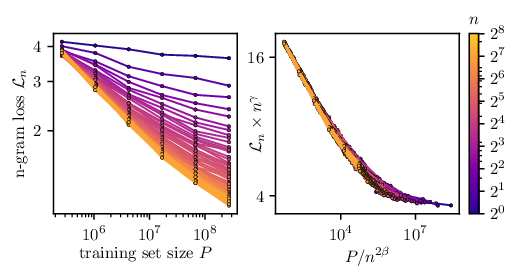

In [63]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

T = 256
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [64]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T256.pdf', bbox_inches="tight")

6 torch.Size([4, 256])


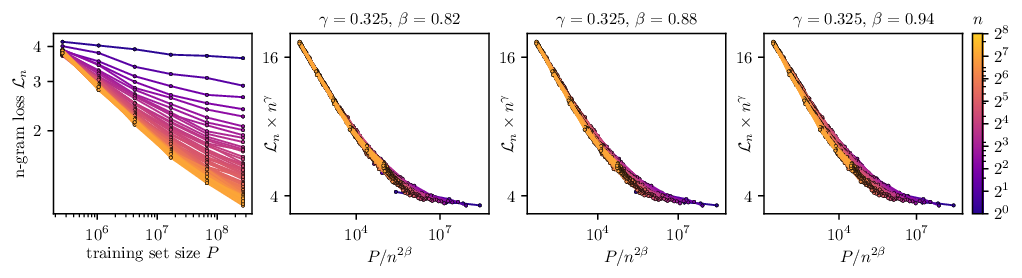

In [65]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 256
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.82)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.88)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.325$, $\beta=0.82$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.325$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [66]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T256__error_beta.pdf', bbox_inches="tight")

6 torch.Size([4, 256])


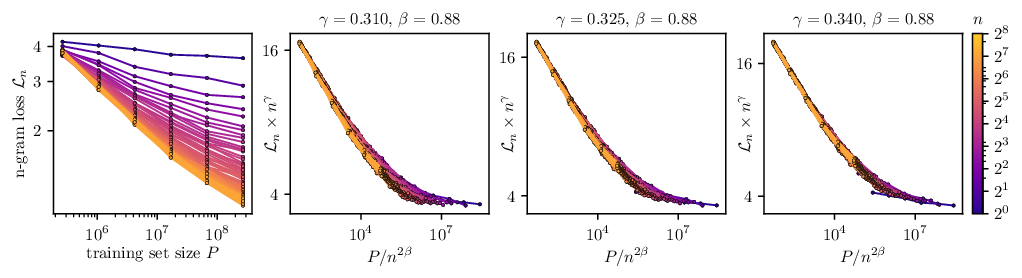

In [67]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 256
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.310 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.340 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.310$, $\beta=0.88$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.340$, $\beta=0.88$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [68]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T256__error_gamma.pdf', bbox_inches="tight")

### GPT2, $T=512$

10 torch.Size([4, 512])


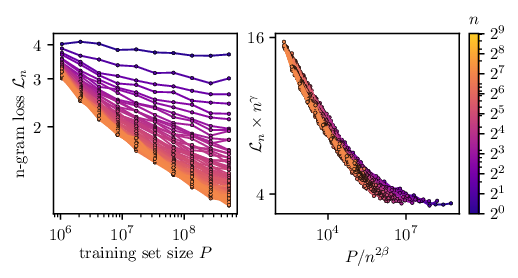

In [69]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

T = 512
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [70]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T512.pdf', bbox_inches="tight")

10 torch.Size([4, 512])


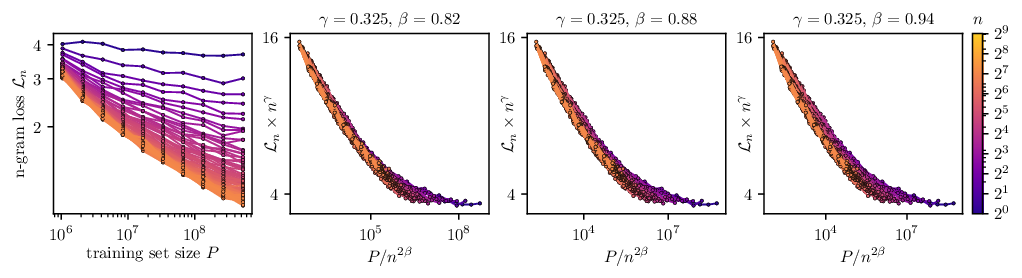

In [71]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 512
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.82)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.88)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.325$, $\beta=0.82$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.325$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [72]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T512__error_beta.pdf', bbox_inches="tight")

10 torch.Size([4, 512])


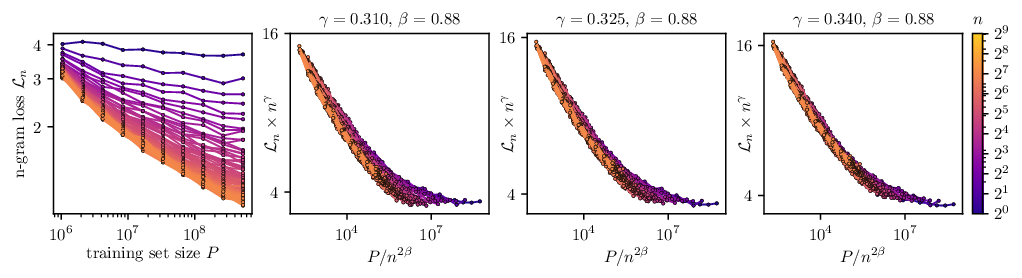

In [73]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 512
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.310 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.340 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.310$, $\beta=0.88$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.340$, $\beta=0.88$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [74]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_APE_T512__error_gamma.pdf', bbox_inches="tight")

### GPT2+RoPE, $T=128$

4 torch.Size([4, 128])


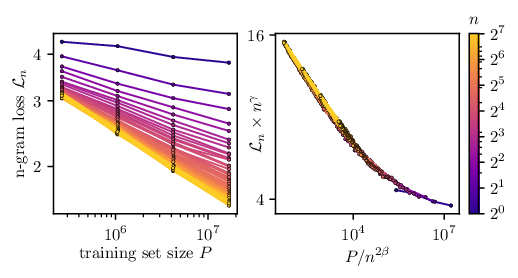

In [76]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

T = 128
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [77]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_RoPE_T128.pdf', bbox_inches="tight")

4 torch.Size([4, 128])


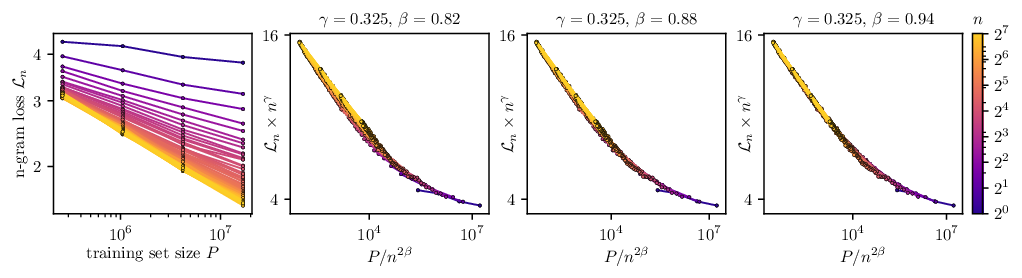

In [78]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 128
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.82)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.88)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.325$, $\beta=0.82$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.325$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [79]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_RoPE_T128__error_beta.pdf', bbox_inches="tight")

4 torch.Size([4, 128])


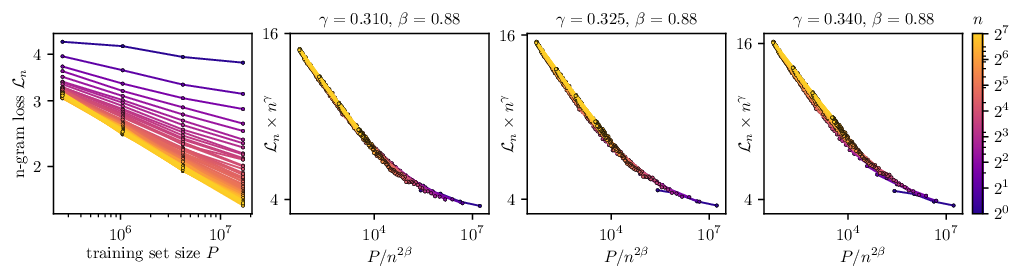

In [80]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 128
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.310 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.340 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.310$, $\beta=0.88$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.340$, $\beta=0.88$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [81]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_RoPE_T128__error_gamma.pdf', bbox_inches="tight")

### GPT2+RoPE, $T=512$

8 torch.Size([4, 512])


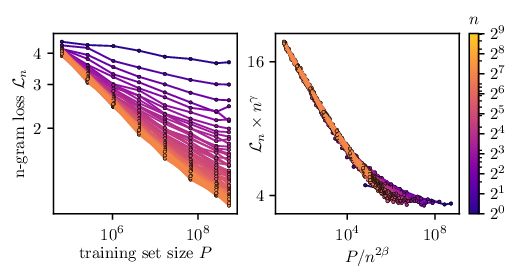

In [103]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

T = 512
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [104]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_RoPE_T512.pdf', bbox_inches="tight")

8 torch.Size([4, 512])


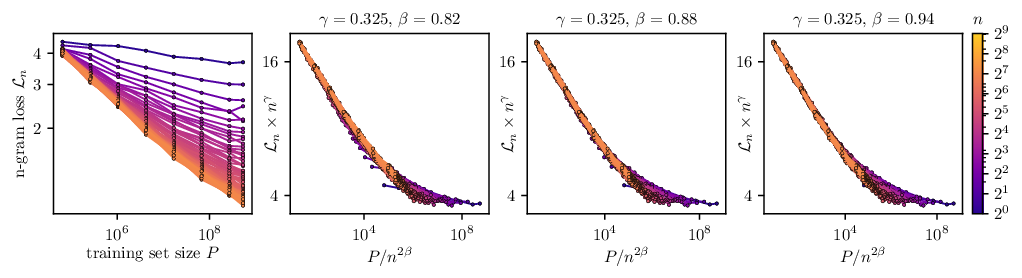

In [105]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 512
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.82)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.88)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.94)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.325$, $\beta=0.82$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.325$, $\beta=0.94$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [106]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_RoPE_T512__error_beta.pdf', bbox_inches="tight")

8 torch.Size([4, 512])


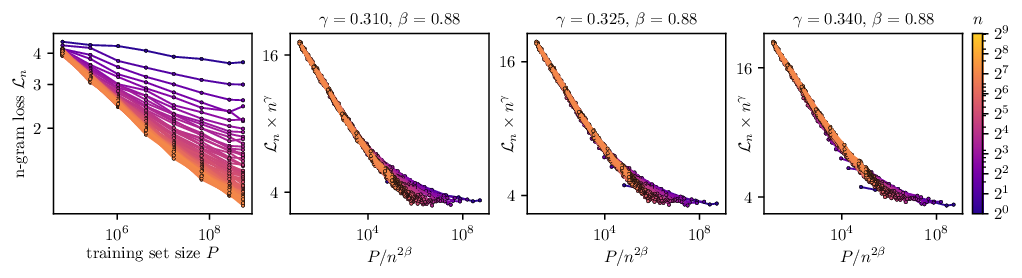

In [107]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 512
depth = 12

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_d{depth}_rope.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.310 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.340 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.310$, $\beta=0.88$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.340$, $\beta=0.88$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [108]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__GPT2_RoPE_T512__error_gamma.pdf', bbox_inches="tight")

### Llama, $T=511$

9 torch.Size([1, 511])


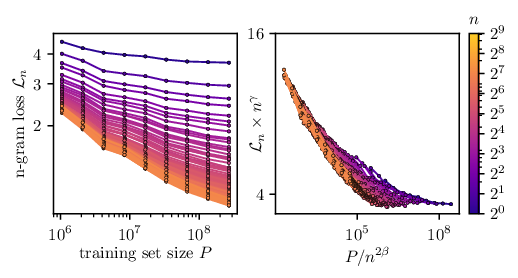

In [109]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

T = 511

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_llama.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [110]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__Llama_T511.pdf', bbox_inches="tight")

9 torch.Size([1, 511])


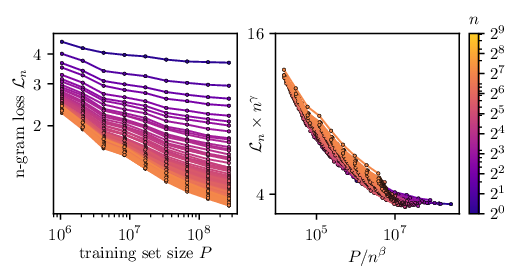

In [111]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(2*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
])

T = 511

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_llama.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)
ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{\beta}$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[2])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [112]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__llama_T511.pdf', bbox_inches="tight")

9 torch.Size([1, 511])


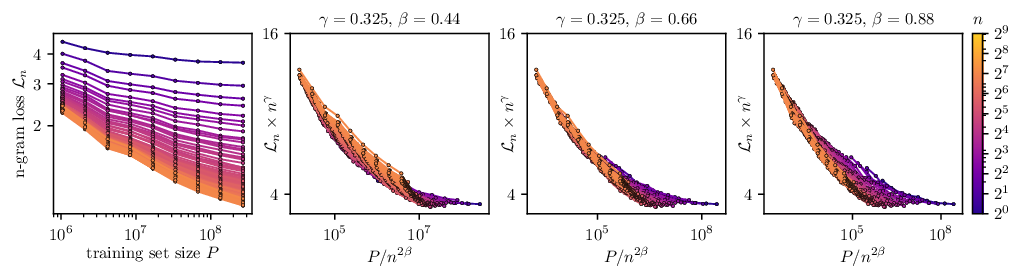

In [113]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 511

gamma = 0.325
beta = 0.88

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_llama.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*0.44)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.66)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*0.88)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.325$, $\beta=0.44$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.66$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.325$, $\beta=0.88$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [114]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__Llama_T512__error_beta.pdf', bbox_inches="tight")

9 torch.Size([1, 511])


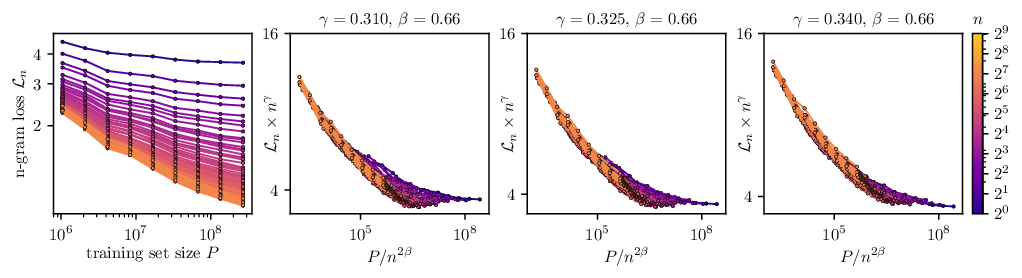

In [115]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
fig = plt.figure(constrained_layout=True, figsize=(4*2.1, 1*2.2), dpi=120)

# example: 2 columns of plots + a colorbar column
gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.02)
ax = np.array([
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
    fig.add_subplot(gs[3]),
])

T = 512
depth = 12

gamma = 0.325
beta = 0.66

results = torch.load(f"tinystories/learning-curves/ngrams_tinystories.BPE8192_T{T}_llama.pt")
print(len(results['ngrams']), results['ngrams'][0].size())
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=1, vmax=T+1)


for t in range(128):

    ax[0].plot([p for p in p_list], [loss[t] for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

    scaling = (t+1)**(2*beta)
    ax[1].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.310 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[2].plot([p/scaling for p in p_list], [loss[t]*(t+1)**gamma for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')
    scaling = (t+1)**(2*beta)
    ax[3].plot([p/scaling for p in p_list], [loss[t]*(t+1)**0.340 for loss in ngrams_list], color=cmap(norm(t+1)), marker='.', markeredgecolor="black", markeredgewidth=0.2, label=f'{t+2}-gram')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_xscale('log')
ax[1].set_yscale('log')

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[3].set_xscale('log')
ax[3].set_yscale('log')

ax[0].set_ylabel(r'n-gram loss $\mathcal{L}_{n}$', fontsize=10)
ax[0].set_xlabel(r'training set size $P$', fontsize=10)

ax[1].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[1].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[1].set_title(r'$\gamma=0.310$, $\beta=0.66$', fontsize=10)

ax[2].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[2].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[2].set_title(r'$\gamma=0.325$, $\beta=0.66$', fontsize=10)

ax[3].set_ylabel(r'$\mathcal{L}_{n}\times n^\gamma$', fontsize=10, labelpad=-10)
ax[3].set_xlabel(r'$P/n^{2\beta}$', fontsize=10)
ax[3].set_title(r'$\gamma=0.340$, $\beta=0.66$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 2, 3, 4]
labels = [ "2", "3", "4"]  # must match length/order
ax[0].set_yticks(ticks)
ax[0].set_yticklabels(labels)
ax[0].yaxis.set_minor_locator(mticker.NullLocator())

ticks  = [4, 16]
labels = [ "4", "16"]  # must match length/order
ax[1].set_yticks(ticks)
ax[1].set_yticklabels(labels)
ax[1].yaxis.set_minor_locator(mticker.NullLocator())
ax[2].set_yticks(ticks)
ax[2].set_yticklabels(labels)
ax[2].yaxis.set_minor_locator(mticker.NullLocator())
ax[3].set_yticks(ticks)
ax[3].set_yticklabels(labels)
ax[3].yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy

cax = fig.add_subplot(gs[4])  # spans both rows -> matches plot stack height
cbar = fig.colorbar(sm, cax=cax)
cbar.ax.set_title(r"$n$", fontsize=10, pad=6)


ticks = 2 ** np.arange(
    int(np.floor(np.log2(1))),
    int(np.ceil(np.log2(T))) + 1
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

In [116]:
fig.savefig('tinystories/'+f'L_n_P_collapse__tinystories.BPE8192__Llama_T511__error_gamma.pdf', bbox_inches="tight")